In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

### Config

In [8]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

### 1. Load Data with Augmentation

In [9]:
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory('data/train', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse')
val_gen = val_datagen.flow_from_directory('data/val', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse')

Found 92 images belonging to 5 classes.
Found 25 images belonging to 5 classes.


In [10]:
train_gen.class_indices.keys()

dict_keys(['ben_afflek', 'elton_john', 'jerry_seinfeld', 'madonna', 'mindy_kaling'])

### 2. Build Model (Transfer Learning)

In [48]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
base_model.trainable = False 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(len(train_gen.class_indices), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### 3. Train and Save

In [ ]:
model.fit(train_gen, validation_data=val_gen, epochs=10) # Cambié a 10 epocas para mejorar la precision
model.save('celebrity_model.h5')

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1087 - loss: 2.1188 - val_accuracy: 0.2800 - val_loss: 1.7000
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 462ms/step - accuracy: 0.3152 - loss: 1.5942 - val_accuracy: 0.4800 - val_loss: 1.5351
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 503ms/step - accuracy: 0.5217 - loss: 1.4011 - val_accuracy: 0.5200 - val_loss: 1.3753
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 451ms/step - accuracy: 0.5978 - loss: 1.1537 - val_accuracy: 0.5600 - val_loss: 1.1923
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 467ms/step - accuracy: 0.6848 - loss: 0.9446 - val_accuracy: 0.5600 - val_loss: 1.0418
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 462ms/step - accuracy: 0.8261 - loss: 0.7868 - val_accuracy: 0.6400 - val_loss: 0.9277
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 495ms/step - accuracy: 0.7717 - loss: 0.7350 - val_accuracy: 0.6800 - val_loss: 0.8492
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 495ms/step - accuracy: 0.8478 - loss: 0.5710 - val_accuracy: 0.7200 - val_loss: 0.

### Store class names for prediction

In [50]:
class_names = list(train_gen.class_indices.keys())
print("Classes identified:", class_names)

Classes identified: ['ben_afflek', 'elton_john', 'jerry_seinfeld', 'madonna', 'mindy_kaling']


## Testing

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


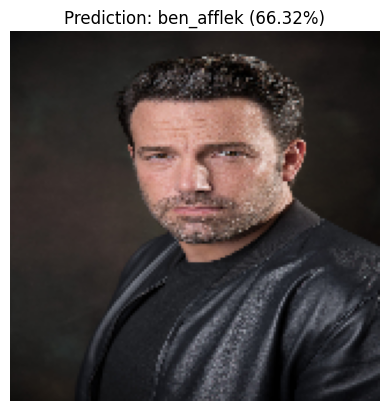

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


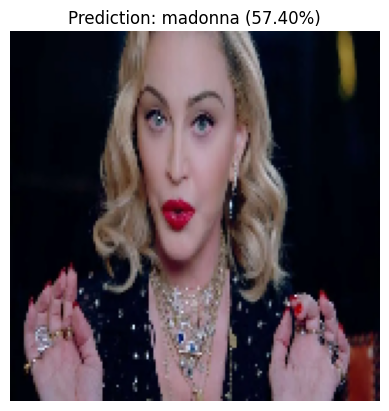

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


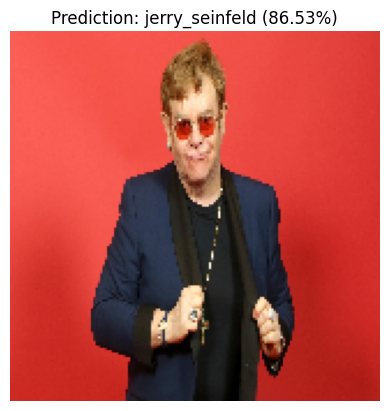

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


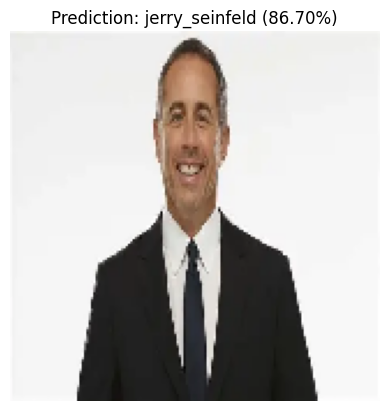

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


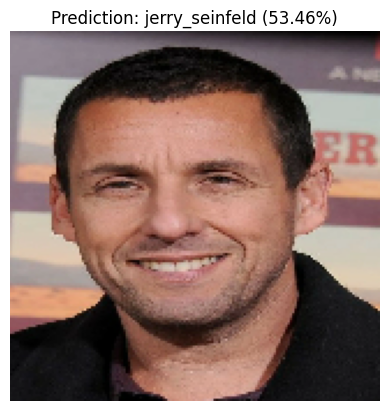

In [51]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_celebrity(img_path, model_path='celebrity_model.h5'):
    # Load model and image
    model = tf.keras.models.load_model(model_path)
    img = image.load_img(img_path, target_size=(160, 160))
    
    # Pre-process
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0) # Create batch axis

    # Predict
    predictions = model.predict(img_array)
    score = np.max(predictions)
    class_idx = np.argmax(predictions)
    
    # Display
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[class_idx]} ({100 * score:.2f}%)")
    plt.axis('off')
    plt.show()

# Usage:
predict_celebrity('ben.jfif')
predict_celebrity('madonna.webp')
predict_celebrity('elton.jpg')
predict_celebrity('jerry.webp')
predict_celebrity('adam.webp')

# Todos son Jerry Seinfeld.